<a href="https://colab.research.google.com/github/coderpalak3109-cyber/Product_Demand_Prediction/blob/main/Food_Demand_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data Collection

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load all files
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
meal_info = pd.read_csv('meal_info.csv')
center_info = pd.read_csv('fulfilment_center_info.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nTrain columns:", train.columns.tolist())
print("Test columns:", test.columns.tolist())

# Merge meal and center info into both train and test
train = train.merge(meal_info, on='meal_id', how='left')
train = train.merge(center_info, on='center_id', how='left')

test = test.merge(meal_info, on='meal_id', how='left')
test = test.merge(center_info, on='center_id', how='left')

print("\nAfter merge - Train shape:", train.shape)
print("After merge - Test shape:", test.shape)
print("\nTrain sample:")
print(train.head(3))

Train shape: (456548, 9)
Test shape: (32573, 8)

Train columns: ['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders']
Test columns: ['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured']

After merge - Train shape: (456548, 15)
After merge - Test shape: (32573, 14)

Train sample:
        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   

   emailer_for_promotion  homepage_featured  num_orders   category cuisine  \
0                      0                  0         177  Beverages    Thai   
1                      0                  0         270  Beverages    Thai   
2                      0                  0         189  Beverages    Tha

# Data Pre-procssing

=== Missing Values in Train ===
id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
category                 0
cuisine                  0
city_code                0
region_code              0
center_type              0
op_area                  0
dtype: int64

=== Missing Values in Test ===
id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
category                 0
cuisine                  0
city_code                0
region_code              0
center_type              0
op_area                  0
dtype: int64

=== Data Types ===
id                         int64
week                       int64
center_id                  int64
meal_id 

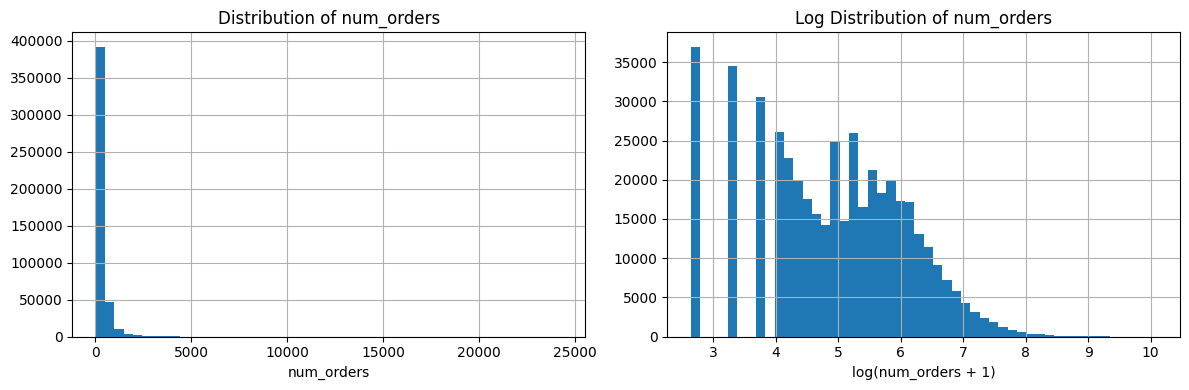


Unique values:
category: 14
cuisine: 4
center_type: 3


In [3]:
# ---- 2a. Check for missing values ----
print("=== Missing Values in Train ===")
print(train.isnull().sum())
print("\n=== Missing Values in Test ===")
print(test.isnull().sum())

# ---- 2b. Check data types ----
print("\n=== Data Types ===")
print(train.dtypes)

# ---- 2c. Basic statistics ----
print("\n=== Target Variable Stats ===")
print(train['num_orders'].describe())

# ---- 2d. Check for outliers in target ----
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
train['num_orders'].hist(bins=50)
plt.title('Distribution of num_orders')
plt.xlabel('num_orders')

plt.subplot(1,2,2)
np.log1p(train['num_orders']).hist(bins=50)
plt.title('Log Distribution of num_orders')
plt.xlabel('log(num_orders + 1)')
plt.tight_layout()
plt.savefig('target_distribution.png')
plt.show()

# The target is right-skewed — we will log-transform it for modeling
# log1p(x) = log(x+1), handles zero values safely

train['log_orders'] = np.log1p(train['num_orders'])

# ---- 2e. Encode categorical columns ----
# category and cuisine are text — convert to category codes
for col in ['category', 'cuisine', 'center_type']:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')

print("\nUnique values:")
print("category:", train['category'].nunique())
print("cuisine:", train['cuisine'].nunique())
print("center_type:", train['center_type'].nunique())

#  Feature Extraction and Selection

In [4]:
# Sort data — critical for lag features
train = train.sort_values(['center_id', 'meal_id', 'week']).reset_index(drop=True)
test = test.sort_values(['center_id', 'meal_id', 'week']).reset_index(drop=True)

# ---- 3a. Price discount feature ----
# How much discount is being offered?
train['discount'] = (train['base_price'] - train['checkout_price']) / train['base_price']
test['discount'] = (test['base_price'] - test['checkout_price']) / test['base_price']

# ---- 3b. Lag features (past orders for same center+meal) ----
# These are the most powerful features for time series forecasting
# We combine train + test to compute lags across the full timeline

full_data = pd.concat([train, test], sort=False)
full_data = full_data.sort_values(['center_id', 'meal_id', 'week']).reset_index(drop=True)

# Group by center+meal combination
group = full_data.groupby(['center_id', 'meal_id'])

# Lag 1: orders from 1 week ago
full_data['lag_1'] = group['num_orders'].shift(1)
# Lag 2: orders from 2 weeks ago
full_data['lag_2'] = group['num_orders'].shift(2)
# Lag 3: orders from 3 weeks ago
full_data['lag_3'] = group['num_orders'].shift(3)

# Rolling mean: average of last 3 weeks
full_data['rolling_mean_3'] = group['num_orders'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)

# Rolling mean: average of last 5 weeks
full_data['rolling_mean_5'] = group['num_orders'].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
)

# Rolling std: variability over last 3 weeks
full_data['rolling_std_3'] = group['num_orders'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).std()
)

# ---- 3c. Week-based features ----
full_data['week_mod_4'] = full_data['week'] % 4   # rough monthly cycle
full_data['week_mod_13'] = full_data['week'] % 13  # rough quarterly cycle

# ---- 3d. Encode categoricals as numbers ----
for col in ['category', 'cuisine', 'center_type']:
    full_data[col] = full_data[col].astype('category').cat.codes

# ---- 3e. Split back into train and test ----
train_fe = full_data[full_data['week'] <= 145].copy()
test_fe  = full_data[full_data['week'] > 145].copy()

print("Train with features shape:", train_fe.shape)
print("Test with features shape:", test_fe.shape)

# ---- 3f. Define features to use ----
FEATURES = [
    'week', 'center_id', 'meal_id',
    'checkout_price', 'base_price', 'discount',
    'emailer_for_promotion', 'homepage_featured',
    'category', 'cuisine',
    'city_code', 'region_code', 'center_type', 'op_area',
    'lag_1', 'lag_2', 'lag_3',
    'rolling_mean_3', 'rolling_mean_5', 'rolling_std_3',
    'week_mod_4', 'week_mod_13'
]

TARGET = 'log_orders'  # log-transformed target

# Drop rows where lag features are NaN (first few weeks per group)
train_clean = train_fe.dropna(subset=['lag_1', 'lag_2', 'lag_3'])
print(f"\nRows after dropping NaN lags: {len(train_clean)} (removed {len(train_fe) - len(train_clean)})")

Train with features shape: (456548, 25)
Test with features shape: (32573, 25)

Rows after dropping NaN lags: 445763 (removed 10785)


# Model Fitting

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import lightgbm as lgb

X = train_clean[FEATURES]
y = train_clean[TARGET]

# Time-based split — use last 10 weeks as validation (more realistic than random split)
val_weeks = train_clean['week'] > 135

X_train = train_clean[~val_weeks][FEATURES]
y_train = train_clean[~val_weeks][TARGET]
X_val   = train_clean[val_weeks][FEATURES]
y_val   = train_clean[val_weeks][TARGET]

print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}")

# ---- Model 1: Linear Regression ----
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_val)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_preds))
print(f"\nLinear Regression Validation RMSE (log scale): {lr_rmse:.4f}")

# ---- Model 2: LightGBM ----
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'n_estimators': 500
}

lgb_model = lgb.LGBMRegressor(**lgb_params)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

lgb_preds = lgb_model.predict(X_val)
lgb_rmse = np.sqrt(mean_squared_error(y_val, lgb_preds))
print(f"\nLightGBM Validation RMSE (log scale): {lgb_rmse:.4f}")

Train size: 412946, Validation size: 32817

Linear Regression Validation RMSE (log scale): 0.7297
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.49945
Early stopping, best iteration is:
[123]	valid_0's rmse: 0.497984

LightGBM Validation RMSE (log scale): 0.4980


# Result Evaluation

=== Model Comparison ===
Metric                    Linear Reg        LightGBM
----------------------------------------------------
RMSLE                         0.7297          0.4980
MAE                           185.58           65.97
R2 Score                   -104.4288          0.8254


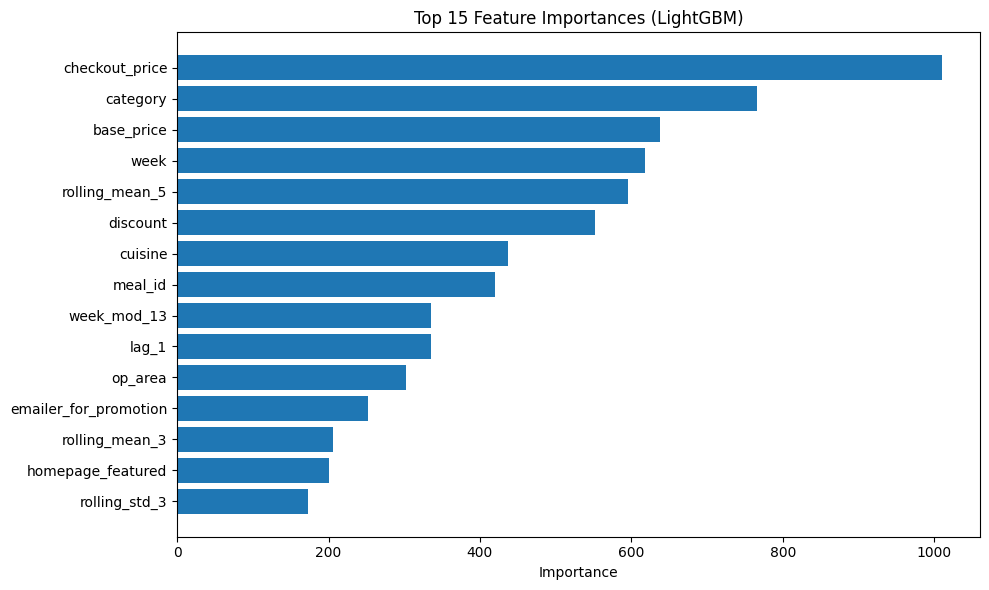


Top 10 Features:
           feature  importance
3   checkout_price        1010
8         category         766
4       base_price         638
0             week         618
18  rolling_mean_5         596
5         discount         552
9          cuisine         437
2          meal_id         420
21     week_mod_13         336
14           lag_1         335


In [6]:
from sklearn.metrics import r2_score

# ---- 5a. Metrics on validation set ----
# Convert predictions back from log scale to actual orders
y_val_actual = np.expm1(y_val)
lr_actual_preds   = np.expm1(lr_preds)
lgb_actual_preds  = np.expm1(lgb_preds)

# RMSLE — this is what Kaggle uses for this competition
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)  # no negative orders
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

print("=== Model Comparison ===")
print(f"{'Metric':<20} {'Linear Reg':>15} {'LightGBM':>15}")
print("-" * 52)
print(f"{'RMSLE':<20} {rmsle(y_val_actual, lr_actual_preds):>15.4f} {rmsle(y_val_actual, lgb_actual_preds):>15.4f}")
print(f"{'MAE':<20} {mean_absolute_error(y_val_actual, lr_actual_preds):>15.2f} {mean_absolute_error(y_val_actual, lgb_actual_preds):>15.2f}")
print(f"{'R2 Score':<20} {r2_score(y_val_actual, lr_actual_preds):>15.4f} {r2_score(y_val_actual, lgb_actual_preds):>15.4f}")

# ---- 5b. Feature importance ----
import matplotlib.pyplot as plt

feat_imp = pd.DataFrame({
    'feature': FEATURES,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['feature'][:15], feat_imp['importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (LightGBM)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print("\nTop 10 Features:")
print(feat_imp.head(10))

# Validation Through Visualization

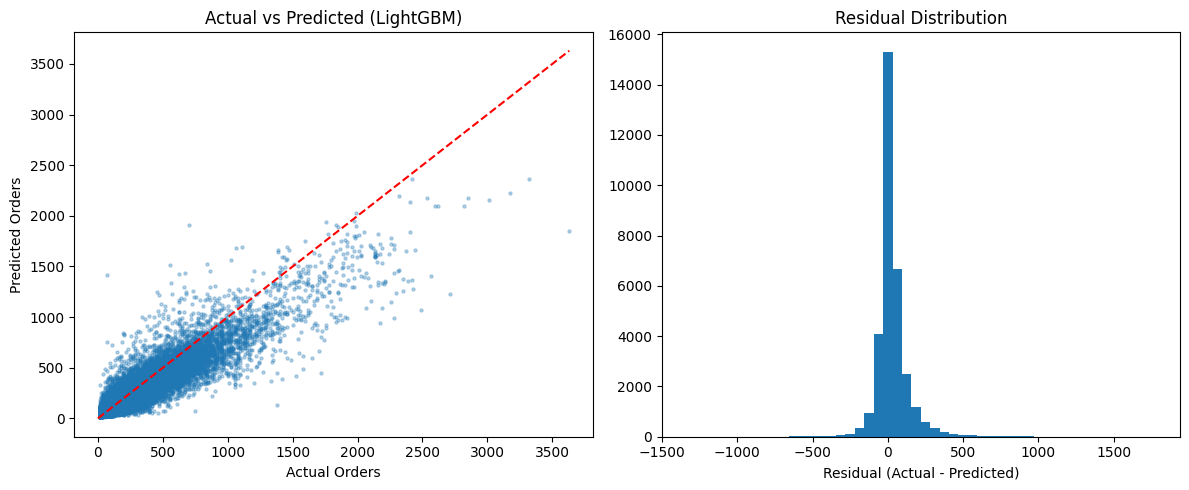

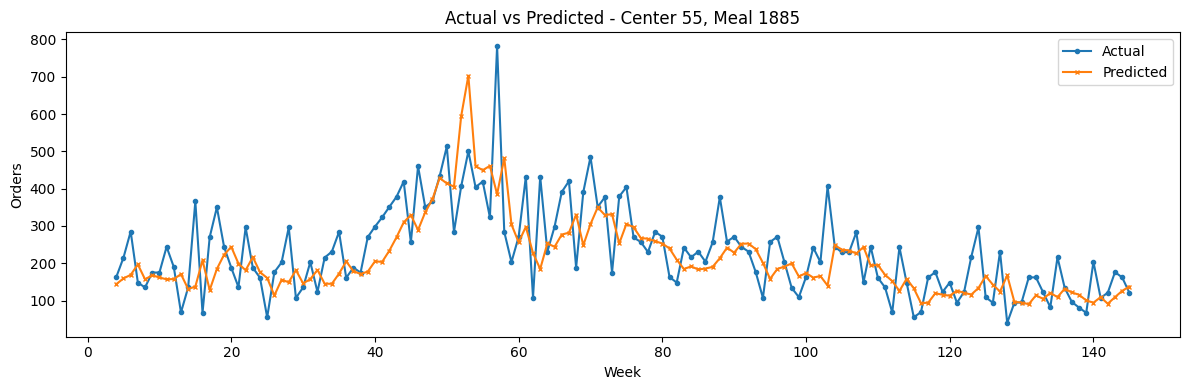


Mean Absolute Error by Promotion Type:
emailer_for_promotion
0     62.636219
1    125.853569
Name: abs_error, dtype: float64

Mean Absolute Error by Homepage Featured:
homepage_featured
0     61.164118
1    119.846838
Name: abs_error, dtype: float64


In [7]:
# ---- 6a. Actual vs Predicted plot ----
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_val_actual, lgb_actual_preds, alpha=0.3, s=5)
plt.plot([0, y_val_actual.max()], [0, y_val_actual.max()], 'r--')
plt.xlabel('Actual Orders')
plt.ylabel('Predicted Orders')
plt.title('Actual vs Predicted (LightGBM)')

plt.subplot(1, 2, 2)
# Residuals
residuals = y_val_actual - lgb_actual_preds
plt.hist(residuals, bins=50)
plt.xlabel('Residual (Actual - Predicted)')
plt.title('Residual Distribution')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

# ---- 6b. Forecast vs Actual over time (pick one center+meal combo) ----
sample = train_clean[(train_clean['center_id'] == 55) & (train_clean['meal_id'] == 1885)].copy()
sample_preds = lgb_model.predict(sample[FEATURES])
sample['predicted'] = np.expm1(sample_preds)

plt.figure(figsize=(12, 4))
plt.plot(sample['week'], sample['num_orders'], label='Actual', marker='o', markersize=3)
plt.plot(sample['week'], sample['predicted'], label='Predicted', marker='x', markersize=3)
plt.xlabel('Week')
plt.ylabel('Orders')
plt.title('Actual vs Predicted - Center 55, Meal 1885')
plt.legend()
plt.tight_layout()
plt.savefig('time_series_validation.png')
plt.show()

# ---- 6c. Error by promotion type ----
val_data = train_clean[val_weeks].copy()
val_data['predicted'] = lgb_actual_preds
val_data['actual'] = y_val_actual
val_data['abs_error'] = abs(val_data['actual'] - val_data['predicted'])

print("\nMean Absolute Error by Promotion Type:")
print(val_data.groupby('emailer_for_promotion')['abs_error'].mean())
print("\nMean Absolute Error by Homepage Featured:")
print(val_data.groupby('homepage_featured')['abs_error'].mean())

# Generating Final Predictions + Export for Dashboard

In [8]:
# ---- 7a. Generate test predictions ----
X_test = test_fe[FEATURES]

# Note: test has NaN lags for some rows (no history). Fill with rolling mean.
X_test = X_test.fillna(X_test.median())

test_log_preds = lgb_model.predict(X_test)
test_preds = np.expm1(test_log_preds)
test_preds = np.maximum(test_preds, 0)  # no negative orders

# ---- 7b. Create submission file ----
submission = pd.DataFrame({
    'id': test_fe['id'].values,
    'num_orders': np.round(test_preds).astype(int)
})
submission.to_csv('submission.csv', index=False)
print("Submission saved. Shape:", submission.shape)
print(submission.head())

# ---- 7c. Export enriched data for Power BI / Tableau dashboard ----
# Combine train + predictions for dashboard use

train_export = train_fe[['week', 'center_id', 'meal_id', 'checkout_price',
                          'base_price', 'discount', 'emailer_for_promotion',
                          'homepage_featured', 'num_orders',
                          'city_code', 'region_code', 'op_area']].copy()
train_export['split'] = 'train'

test_export = test_fe[['week', 'center_id', 'meal_id', 'checkout_price',
                        'base_price', 'discount', 'emailer_for_promotion',
                        'homepage_featured',
                        'city_code', 'region_code', 'op_area']].copy()
test_export['num_orders'] = np.round(test_preds).astype(int)
test_export['split'] = 'predicted'

dashboard_data = pd.concat([train_export, test_export], ignore_index=True)

# Merge back readable category names (not encoded numbers)
meal_readable = pd.read_csv('meal_info.csv')
center_readable = pd.read_csv('fulfilment_center_info.csv')
dashboard_data = dashboard_data.merge(meal_readable, on='meal_id', how='left')
dashboard_data = dashboard_data.merge(center_readable[['center_id','center_type']], on='center_id', how='left')

dashboard_data.to_csv('dashboard_export.csv', index=False)
print("\nDashboard export saved. Shape:", dashboard_data.shape)
print(dashboard_data.head())

Submission saved. Shape: (32573, 2)
        id  num_orders
0  1177098         903
1  1486011         294
2  1301735         274
3  1273097         237
4  1450902         242

Dashboard export saved. Shape: (489121, 16)
   week  center_id  meal_id  checkout_price  base_price  discount  \
0     1         10     1062          181.39      181.39  0.000000   
1     2         10     1062          183.36      182.36 -0.005484   
2     3         10     1062          184.36      182.36 -0.010967   
3     4         10     1062          182.36      183.36  0.005454   
4     5         10     1062          183.39      181.39 -0.011026   

   emailer_for_promotion  homepage_featured  num_orders  city_code  \
0                      0                  0       865.0        590   
1                      0                  0       782.0        590   
2                      0                  0       851.0        590   
3                      0                  0      1202.0        590   
4               